## Requires Python>=3.9

In [ ]:
# replace the filepath of requirements.txt  with your filepath
! pip install -r "requirements.txt"

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.applications import DenseNet121, DenseNet169, DenseNet201, VGG16, VGG19, MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, MaxPooling2D, BatchNormalization, Input, concatenate, Activation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.metrics import Mean, BinaryCrossentropy, Precision, Recall, AUC
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.preprocessing import LabelEncoder
import pickle


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2, l1_l2, l1
from tensorflow.keras.initializers import he_normal
from tensorflow.keras.metrics import categorical_crossentropy, binary_crossentropy

from sklearn.utils.class_weight import compute_class_weight
from itertools import chain
import sklearn.metrics
import keras
from tensorflow.keras.initializers import GlorotNormal, he_normal
from keras.layers import Input, Lambda

# Check for GPU AND CPU devices available

In [ ]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Define Parameters

In [ ]:
batch_size = 32
target_size = (224, 224)
input_shape = (*target_size, 3)
print('Input shape:',input_shape)

Input shape: (224, 224, 3)


# Dataset Path

Dataset link : https://drive.google.com/file/d/1QDFX4913Fqqs8Od9FqrjMztLEtadLiG2/view?usp=sharing

In [ ]:
import os
dataset_path = os.path.join(r'F:\train_models\data\mackerel')
# dataset_path = os.path.join(r'D:\Dataset_to_prepare\mackerel')

In [ ]:
test_path = os.path.join(dataset_path,'test')
train_path = os.path.join(dataset_path,'train')
val_path = os.path.join(dataset_path,'val')
test_path

'F:\\train_models\\data\\mackerel\\test'

# Pre-processing Functions

In [ ]:
def process_image(image):
    resized_image = cv2.resize(image,target_size)
    processed_image = tf.keras.applications.densenet.preprocess_input(resized_image)
    return processed_image

def histogram_equalization(image):
    if image.dtype != np.uint8:
        image = cv2.convertScaleAbs(image, None, alpha=255.0)
    if len(image.shape) > 2:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if image.dtype != np.uint8:
        image = cv2.convertScaleAbs(image, None, alpha=255.0)
    hist_equalized_image = cv2.equalizeHist(image)
    return cv2.cvtColor(hist_equalized_image, cv2.COLOR_GRAY2RGB)

def contrast_equalization(image):
    if image.dtype != np.uint8:
        image = cv2.convertScaleAbs(image, None, alpha=255.0)
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    lab_planes = list(cv2.split(lab_image))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab_planes[0] = clahe.apply(lab_planes[0])
    equalized_image = cv2.merge(lab_planes)
    equalized_image = cv2.cvtColor(equalized_image, cv2.COLOR_LAB2BGR)
    return equalized_image

def resize_image(image, size):
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)
    resized_image = cv2.resize(image, (new_w, new_h))
    padded_image = pad_image(resized_image, size)
    return padded_image

def pad_image(image, size):
    h, w = image.shape[0],image.shape[1]
    pad_h = (size[1] - h) // 2
    pad_w = (size[0] - w) // 2
    padded_image = cv2.copyMakeBorder(
        image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    return padded_image


    return equalized_image

def load_image(image_path):
    image = cv2.imread(image_path)
    processed_image = process_image(image)
    return processed_image

# Image Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=process_image,  # Your custom preprocessing function
    rotation_range=45,  # Reduce rotation range for phone images (less drastic)
    width_shift_range=0.1,  # Increase width/height shift range for mobile variations
    height_shift_range=0.1,
    shear_range=0.05,  # Further reduce shear for more natural appearance
    zoom_range=0.1,  # Increase zoom range to cover phone zooming
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],  # Wider brightness range for diverse lighting
    channel_shift_range=20,  # Increase channel shift for color variations
    fill_mode='constant',
    cval=0
)


test_datagen = ImageDataGenerator(
    preprocessing_function=process_image,
)



# Data Generators

In [ ]:
train = train_datagen.flow_from_directory(
    directory = train_path,
    target_size=target_size,
    batch_size=batch_size,
    shuffle=True,
    class_mode='binary',
)

class_weights = compute_class_weight(
    'balanced', classes=np.unique(train.classes), y=train.classes
)
class_weights_dict = dict(zip(np.unique(train.classes), class_weights))

# Print the computed class weights
print("Class Weights:", class_weights_dict)

val = test_datagen.flow_from_directory(
    directory = val_path,
    target_size=target_size,
    batch_size=batch_size,
    shuffle=False,
    class_mode='binary',
)
test = test_datagen.flow_from_directory(
    directory = test_path,
    target_size=target_size,
    batch_size=batch_size,
    shuffle=False,
    class_mode='binary',
)

Found 26200 images belonging to 2 classes.
Class Weights: {0: 1.320431408124181, 1: 0.8047177345045764}
Found 3151 images belonging to 2 classes.
Found 3163 images belonging to 2 classes.


# Visualize Augmented and Preprocessed training data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..1.8905448].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.3611329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.5877128].
Clip

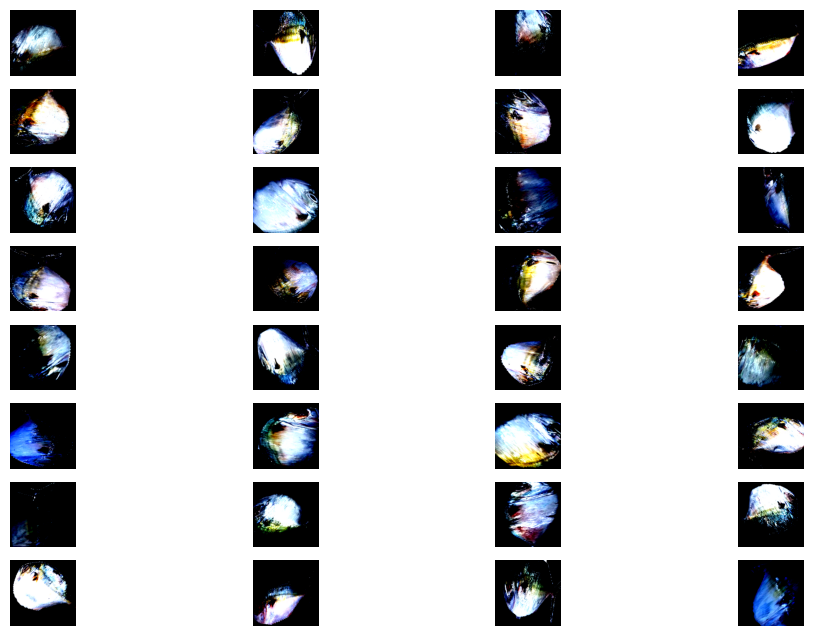

In [ ]:
import matplotlib.pyplot as plt

# Extract a batch of images from the generator
batch_size = 32
images, _ = train.next()
# Visualize the images in the batch
plt.figure(figsize=(12, 8))
for i in range(batch_size):
    plt.subplot(8, 4, i+1)
    plt.imshow((images[i]))
    plt.axis('off')
plt.show()


# Load existing model (Current model)

In [ ]:
model = tf.keras.models.load_model(r'f:/Latest_MACKEREL_DATASETS/MODELS_AND_SCRIPTS/f1.h5')
model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy']) #, clipvalue=1.0
train_steps_per_epoch = len(train)
val_steps_per_epoch = len(val)

In [ ]:
model.summary(show_trainable=True)

Model: "sequential"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   Y          
                                                                            
 global_average_pooling2d (G  (None, 1024)             0         Y          
 lobalAveragePooling2D)                                                     
                                                                            
 dense (Dense)               (None, 128)               131200    Y          
                                                                            
 batch_normalization (BatchN  (None, 128)              512       Y          
 ormalization)                                                              
                                                                            
 dropout (Dropout)           (None, 128)               0

# Evaluate Before fine tuning

In [ ]:
with tf.device('/GPU:0'):
    model.evaluate(test)

99/99 [==============================] - 177s 1s/step - loss: 8.2441 - accuracy: 0.8837


# Call backs

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define the callback
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-7,
    verbose=1,
    mode = 'min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

import sklearn

def f1_from_roc(fpr, tpr, pos, neg):
    """Calculate f1 score from roc values.

    Parameters
    ----------
        fpr : float
            The false positive rate.
        tpr : float
            The true positive rate.
        pos : int
            The number of positive labels.
        neg : int
            The number of negative labels.

    Returns
    -------
    float
        The f1 score.
    """
    fp = fpr * neg
    fn = (1 - tpr) * pos
    tp = pos - fn
    f1 = tp / (tp + ((fn + fp) / 2))
    return f1

def pos_neg(labels, pos_label):
    pos = sum(label == pos_label for label in labels)
    neg = sum(label != pos_label for label in labels)
    return pos, neg

def best_f1_score(labels, predictions, pos_label):
    """Calculate best f1 score with its threshold."""
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, predictions, pos_label=pos_label)
    pos, neg = pos_neg(labels, 1)

    best_f1 = -1
    best_f1_threshold = -1

    for fpr_value, tpr_value, t in zip(fpr, tpr, thresholds):
        f1 = f1_from_roc(fpr_value, tpr_value, pos, neg)
        if f1 > best_f1:
            best_f1 = f1
            best_f1_threshold = t
    return best_f1, best_f1_threshold


import sklearn.metrics
import numpy as np
import keras
import tensorflow as tf
from keras.models import save_model


class BinaryClassifierMetricsCallback(keras.callbacks.Callback):
    def __init__(self, val_data, val_labels, pos_label=1, save_path_roc=None, save_path_precision=None, save_path_f1=None):
        super().__init__()
        self.val_data = val_data
        self.val_labels = val_labels
        self.pos_label = pos_label
        self.save_path_roc = save_path_roc
        self.save_path_precision = save_path_precision
        self.save_path_f1 = save_path_f1
        self.best_roc_auc = float('-inf')  # Initialize with negative infinity
        self.best_precision = float('-inf')
        self.best_f1 = float('-inf')
        self.best_f1_threshold_roc = None
        self.best_f1_threshold_precision = None
        self.best_f1_threshold_f1 = None

    def on_epoch_end(self, epoch, logs={}):
        logs = logs or {}
        predict_results = self.model.predict(self.val_data)

        round_predict_results = np.rint(predict_results)

        roc_auc = sklearn.metrics.roc_auc_score(self.val_labels, predict_results)
        logs["roc_auc"] = roc_auc

        average_precision = sklearn.metrics.average_precision_score(self.val_labels, predict_results,
                                                                    pos_label=self.pos_label)
        logs['average_precision'] = average_precision

        f1, f1_threshold = best_f1_score(self.val_labels, predict_results, self.pos_label)
        logs["f1"] = f1
        logs["best_f1_threshold"] = f1_threshold

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_f1_threshold_f1 = f1_threshold  # Update best F1 threshold for F1 score
            if self.save_path_f1:
                self.model.save(f"{self.save_path_f1}.h5")
                print(f"Epoch {epoch + 1}: Model saved with best F1 score: {f1}")


        if roc_auc > self.best_roc_auc:
            self.best_roc_auc = roc_auc
            self.best_f1_threshold_roc = f1_threshold  # Update best F1 threshold for F1 score
            if self.save_path_roc:
                # save_model(self.model, f"{self.save_path_roc}.h5")
                self.model.save(f"{self.save_path_roc}.h5")
                print(f"Epoch {epoch + 1}: Model saved with best roc_auc score: {roc_auc}")

        if average_precision > self.best_precision:
            self.best_precision = average_precision
            self.best_f1_threshold_precision = f1_threshold  # Update best F1 threshold for F1 score
            if self.save_path_precision:
                # save_model(self.model, f"{self.save_path_precision}.h5")
                self.model.save(f"{self.save_path_precision}.h5")
                print(f"Epoch {epoch + 1}: Model saved with best average_precision score: {average_precision}")

    def get_best_thresholds(self):
        return {
            "roc_auc": self.best_f1_threshold_roc,
            "average_precision": self.best_f1_threshold_precision,
            "f1": self.best_f1_threshold_f1
        }

    def set_gpu_mem_growth():

        config = tf.ConfigProto()
        config.gpu_options.allow_growth = True
        keras.backend.tensorflow_backend.set_session(tf.Session(config=config))


callback = BinaryClassifierMetricsCallback(val, val.classes, pos_label=1,
                                          save_path_roc='roc',
                                          save_path_precision='precision',
                                          save_path_f1='f1')

In [ ]:
best_thresholds = callback.get_best_thresholds()
best_thresholds

{'roc_auc': None, 'average_precision': None, 'f1': None}

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

# Setup the early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',     # Monitor the validation loss
    min_delta=0.001,        # Minimum change to qualify as an improvement
    patience=5,            # Number of epochs with no improvement after which training will be stopped
    verbose=1,              # Level of verbosity
    mode='min',             # In 'min' mode, training will stop when the quantity monitored has stopped decreasing
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

# Define the callback
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-7,
    verbose=1,
    mode = 'min'
)

# Train model

In [ ]:
with tf.device('/GPU:0'):
    history = model.fit(
        train,
        validation_data=val,
        validation_steps=val_steps_per_epoch,
        epochs=50,
        callbacks=[early_stop, callback, reduce_lr_callback], #, dynamic_augmentation_callback, callback, reduce_lr_callback
        class_weight=class_weights_dict
    )

Epoch 1/50
99/99 [==============================] - 37s 314ms/step
Epoch 1: Model saved with best F1 score: 0.9135864135864136
Epoch 1: Model saved with best roc_auc score: 0.953135309322178
Epoch 1: Model saved with best average_precision score: 0.969910550874869
819/819 [==============================] - 2312s 3s/step - loss: 8.1363 - accuracy: 0.9237 - val_loss: 8.2388 - val_accuracy: 0.8807 - roc_auc: 0.9531 - average_precision: 0.9699 - f1: 0.9136 - best_f1_threshold: 0.1679 - lr: 1.0000e-05
Epoch 2/50
99/99 [==============================] - 15s 156ms/step
Epoch 2: Model saved with best roc_auc score: 0.9536246301397816
Epoch 2: Model saved with best average_precision score: 0.9706850883224869
819/819 [==============================] - 975s 1s/step - loss: 8.1343 - accuracy: 0.9223 - val_loss: 8.2485 - val_accuracy: 0.8791 - roc_auc: 0.9536 - average_precision: 0.9707 - f1: 0.9129 - best_f1_threshold: 0.1649 - lr: 1.0000e-05
Epoch 3/50
99/99 [==============================] - 16s

# Training Plots for model fine tuning

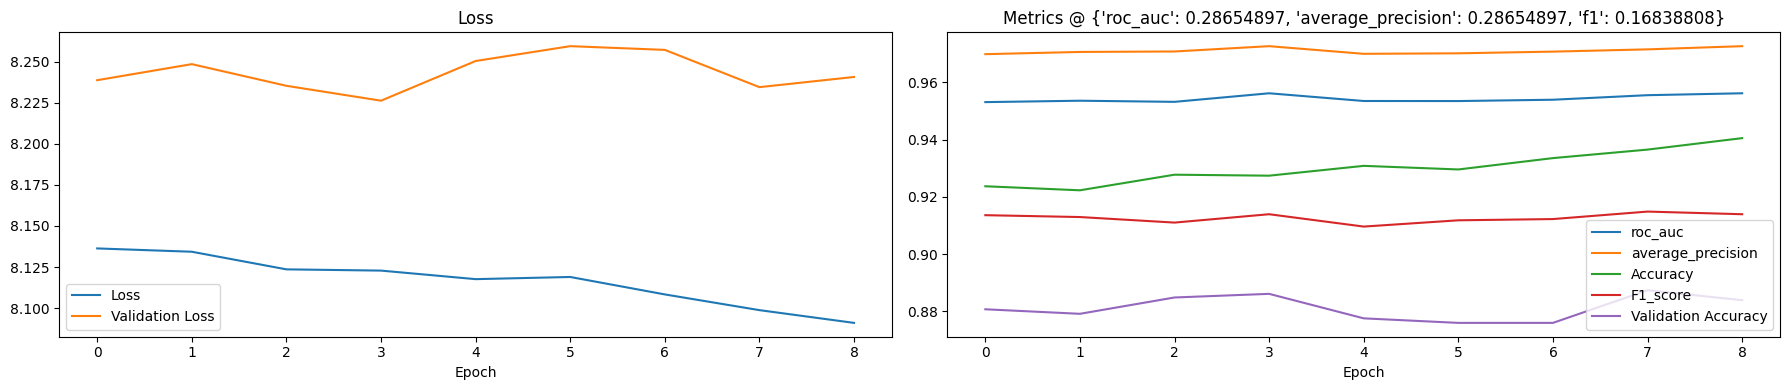

In [ ]:
best_thresholds = callback.get_best_thresholds()

# Plot ROC AUC, average precision, F1 score, loss, and accuracy
plt.figure(figsize=(18, 4))

# ROC AUC
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()


# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['roc_auc'], label='roc_auc')
plt.plot(history.history['average_precision'], label='average_precision')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['f1'], label='F1_score')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'Metrics @ {best_thresholds}')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Model evaluation with Confusion Matrix and Classification reports

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes, threshold,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title + f'  Threshold:{threshold:.2f}')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def evaluate_binary_classification_model(model, test_generator, threshold=0.5):
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, verbose=1)
    y_pred_labels = (y_pred_prob > threshold).astype(int)

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=test_generator.class_indices.keys()))

    # Plot confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred_labels)
    plot_confusion_matrix(cnf_matrix, classes=test_generator.class_indices.keys(), threshold=threshold)

99/99 [==============================] - 17s 167ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.83      0.88      0.86      1215
        good       0.92      0.89      0.91      1936

    accuracy                           0.89      3151
   macro avg       0.88      0.89      0.88      3151
weighted avg       0.89      0.89      0.89      3151

Confusion matrix, without normalization


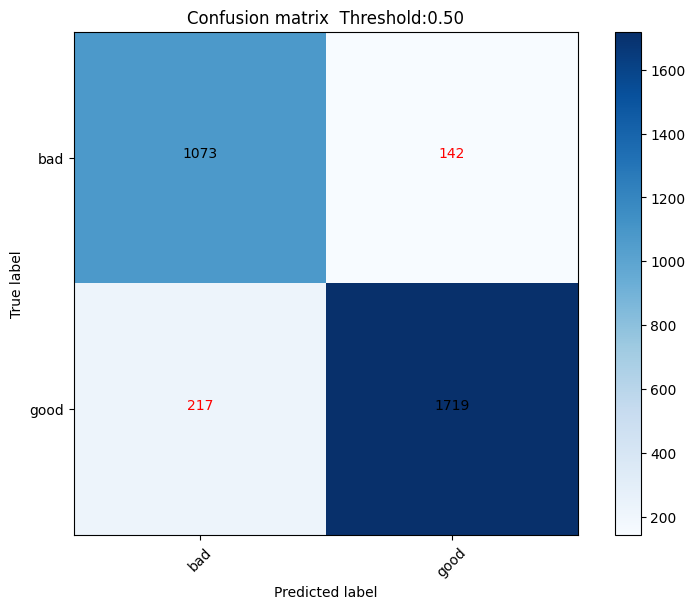

In [ ]:
evaluate_binary_classification_model(model,val )

99/99 [==============================] - 68s 689ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.83      0.89      0.86      1219
        good       0.93      0.88      0.91      1944

    accuracy                           0.89      3163
   macro avg       0.88      0.89      0.88      3163
weighted avg       0.89      0.89      0.89      3163

Confusion matrix, without normalization


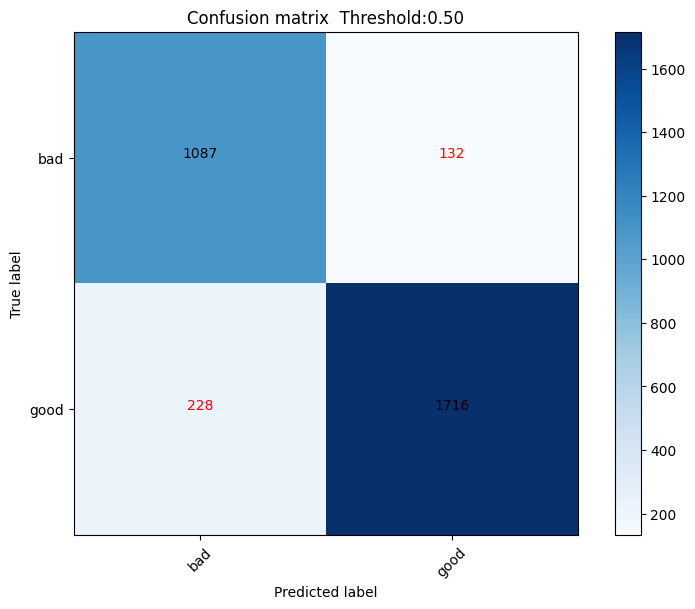

In [ ]:
evaluate_binary_classification_model(model,test )

In [ ]:
def print_layer_properties(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dropout):
            print(f"Layer {layer.name}: Dropout Rate = {layer.rate}")
        elif isinstance(layer, tf.keras.layers.Dense) and layer.kernel_regularizer:
            l2_reg_value = layer.kernel_regularizer.get_config()['l2']
            print(f"Layer {layer.name}: L2 Regularization = {l2_reg_value}")


# Print dropout rates and L2 regularization values for each layer
print_layer_properties(model)

Layer dense: L2 Regularization = 0.009999999776482582
Layer dropout: Dropout Rate = 0.4
Layer dense_1: L2 Regularization = 0.009999999776482582
Layer dropout_1: Dropout Rate = 0.3
Layer dense_2: L2 Regularization = 0.009999999776482582
Layer dropout_2: Dropout Rate = 0.2
Layer dense_3: L2 Regularization = 0.009999999776482582


# Precision, ROC, F1_MODEL TEST

In [ ]:
f1_model = tf.keras.models.load_model('f1.h5')
roc = tf.keras.models.load_model('roc.h5')
precision = tf.keras.models.load_model('precision.h5')

99/99 [==============================] - 18s 169ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.88      0.82      0.85      1219
        good       0.89      0.93      0.91      1944

    accuracy                           0.89      3163
   macro avg       0.89      0.87      0.88      3163
weighted avg       0.89      0.89      0.89      3163

Confusion matrix, without normalization


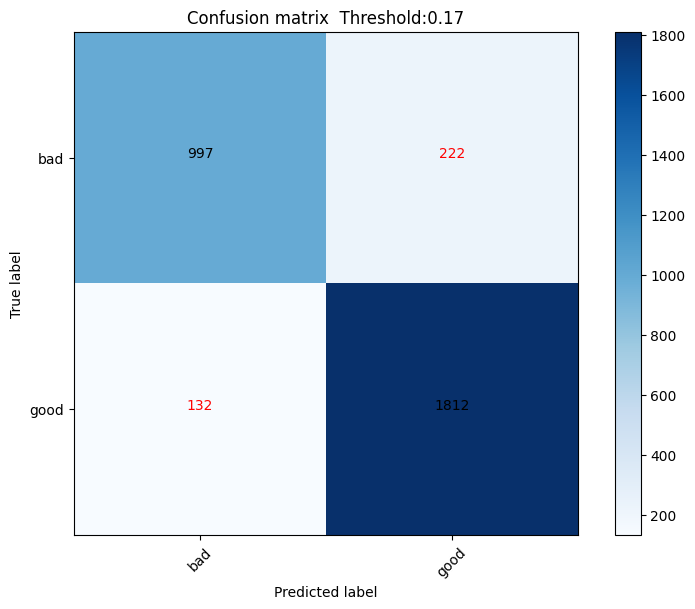

In [ ]:
evaluate_binary_classification_model(f1_model,test,best_thresholds['f1'])

99/99 [==============================] - 18s 167ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.87      0.84      0.85      1219
        good       0.90      0.92      0.91      1944

    accuracy                           0.89      3163
   macro avg       0.89      0.88      0.88      3163
weighted avg       0.89      0.89      0.89      3163

Confusion matrix, without normalization


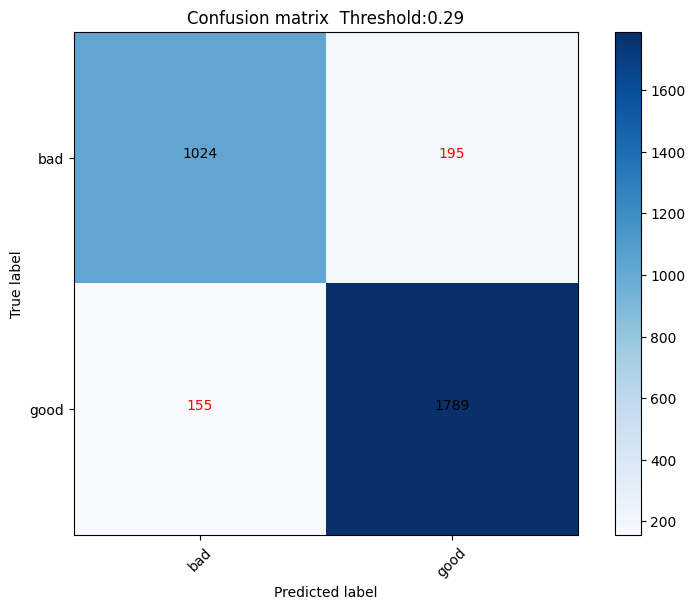

In [ ]:
evaluate_binary_classification_model(roc,test,best_thresholds['roc_auc'])

99/99 [==============================] - 19s 172ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.87      0.84      0.85      1219
        good       0.90      0.92      0.91      1944

    accuracy                           0.89      3163
   macro avg       0.89      0.88      0.88      3163
weighted avg       0.89      0.89      0.89      3163

Confusion matrix, without normalization


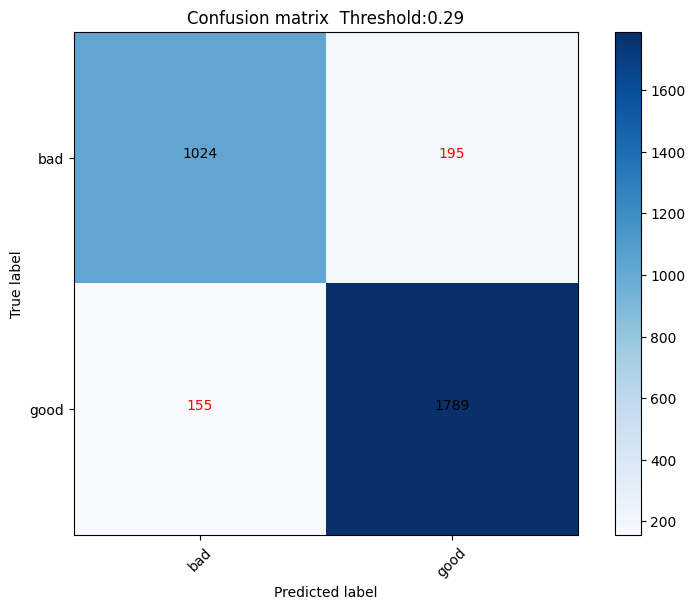

In [ ]:
evaluate_binary_classification_model(precision,test,best_thresholds['average_precision'])